# Notebook 3 – Porto Seguro Safe Driver Prediction (Classification)

## Overview
We benchmark six tabular-learning methods on the Porto Seguro dataset:
**Tabular ResNet**, **FT-Transformer**, **XGBoost**, **LightGBM**, **Random Forest** and **Logistic Regression**.  
Each model is tuned with **Optuna** (20 trials) and evaluated across 3 seeds.  
Metrics: **Accuracy**, **AUC-ROC**, **PR-AUC** , **F1**.

> **Note:** The dataset is heavily imbalanced (~3.6 % positives). PR-AUC provides a better metric for imbalanced datasets
> as it is designed to focus specifically on the positive, typically rarer class, which is much more informative.


In [ ]:
# Package installation (uncomment if needed)
# !pip install rtdl_revisiting_models optuna xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn shap

## Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import time

import random, os, zipfile, gc, io, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from rtdl_revisiting_models import FTTransformer
from rtdl_revisiting_models import ResNet as _RTDLResNet
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, average_precision_score
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

Using device: cuda
cudnn.benchmark  = True


## Configuration
These parameters denote the key parameters for the experiments.
- SEEDS: Set 3 specific seed numbers
- N_OPTUNA_TRIALS: Number of trials to run for Optuna hyperparameter tuning
- TEST_SIZE: Proportion of data used for train-test split
- VAL_FRAC: Proportion of training data divided into train-validation (effectively 60/20/20 for train/val/test split)
- N_PATIENCE: Number of trials for early stopping when validation performance stops improving
- OPT_EPOCHS: Number of epochs to run for Optuna hyperparameter tuning
- FT_EPOCHS: Number of epochs to run when training across seeds
- N_BATCH_SIZE: Number of mini-batches used when training neural network models

In [3]:
SEEDS           = [42, 123, 456]
N_OPTUNA_TRIALS = 20
TEST_SIZE       = 0.20
VAL_FRAC        = 0.25
N_PATIENCE      = 10
OPT_EPOCHS      = 50
TR_EPOCHS       = 100
N_BATCH_SIZE    = 1024

## Data Loading & Exploratory Data Analysis (EDA)
- Load dataset from zip file and extract into subfolder
- Inspect shape, data types, and cardinality of features
- Check for missing values using "-1" indicator

In [4]:
# Create data directory and load the dataset
os.makedirs('data/porto_seguro', exist_ok=True)
df = None
zip_path = 'data/porto-seguro-safe-driver-prediction.zip'

try:
    # Open the existing ZIP file and extract
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('data/porto_seguro')

    # Load the training CSV directly
    csv_path = 'data/porto_seguro/train.csv'
    df = pd.read_csv(csv_path)
    print(f"Loaded training data: {df.shape}")

    # Load the test CSV directly
    test_csv_path = 'data/porto_seguro/test.csv'
    df_test = pd.read_csv(test_csv_path)
    print(f"Loaded test data: {df_test.shape}")

except Exception as e:
    print(f"Failed to read from local ZIP: {e}")
    print("Please make sure the file exists at:")
    print(zip_path)
    df = None
    df_test = None

Loaded training data: (595212, 59)
Loaded test data: (892816, 58)


In [5]:
print("Shape:", df.shape)
print()
print("Target distribution:")
print(df['target'].value_counts())
print(f"Positive rate: {df['target'].mean():.3%}")

Shape: (595212, 59)

Target distribution:
target
0    573518
1     21694
Name: count, dtype: int64
Positive rate: 3.645%


In the train and test data, features that belong to similar groupings are tagged as such in the feature names (e.g., ind, reg, car, calc). In addition, feature names include the postfix "_bin" to indicate binary features and "_cat" to indicate categorical features. Features without these designations are either continuous or ordinal.

In [6]:
# Check for categorical and numerical columns
df.columns

Index(['id', 'target', 'ps_ind_01', 'ps_ind_02_cat', 'ps_ind_03',
       'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_ind_06_bin', 'ps_ind_07_bin',
       'ps_ind_08_bin', 'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin',
       'ps_ind_12_bin', 'ps_ind_13_bin', 'ps_ind_14', 'ps_ind_15',
       'ps_ind_16_bin', 'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_reg_01',
       'ps_reg_02', 'ps_reg_03', 'ps_car_01_cat', 'ps_car_02_cat',
       'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat',
       'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat',
       'ps_car_11_cat', 'ps_car_11', 'ps_car_12', 'ps_car_13', 'ps_car_14',
       'ps_car_15', 'ps_calc_01', 'ps_calc_02', 'ps_calc_03', 'ps_calc_04',
       'ps_calc_05', 'ps_calc_06', 'ps_calc_07', 'ps_calc_08', 'ps_calc_09',
       'ps_calc_10', 'ps_calc_11', 'ps_calc_12', 'ps_calc_13', 'ps_calc_14',
       'ps_calc_15_bin', 'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin',
       'ps_calc_19_bin', 'ps_calc_20_bin'],


In [ ]:
# Print the number of unique values in each column to check for ordinality and high-cardinality features
print("Number of unique values in each column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Number of unique values in each column:
id: 595212
target: 2
ps_ind_01: 8
ps_ind_02_cat: 5
ps_ind_03: 12
ps_ind_04_cat: 3
ps_ind_05_cat: 8
ps_ind_06_bin: 2
ps_ind_07_bin: 2
ps_ind_08_bin: 2
ps_ind_09_bin: 2
ps_ind_10_bin: 2
ps_ind_11_bin: 2
ps_ind_12_bin: 2
ps_ind_13_bin: 2
ps_ind_14: 5
ps_ind_15: 14
ps_ind_16_bin: 2
ps_ind_17_bin: 2
ps_ind_18_bin: 2
ps_reg_01: 10
ps_reg_02: 19
ps_reg_03: 5013
ps_car_01_cat: 13
ps_car_02_cat: 3
ps_car_03_cat: 3
ps_car_04_cat: 10
ps_car_05_cat: 3
ps_car_06_cat: 18
ps_car_07_cat: 3
ps_car_08_cat: 2
ps_car_09_cat: 6
ps_car_10_cat: 3
ps_car_11_cat: 104
ps_car_11: 5
ps_car_12: 184
ps_car_13: 70482
ps_car_14: 850
ps_car_15: 15
ps_calc_01: 10
ps_calc_02: 10
ps_calc_03: 10
ps_calc_04: 6
ps_calc_05: 7
ps_calc_06: 11
ps_calc_07: 10
ps_calc_08: 11
ps_calc_09: 8
ps_calc_10: 26
ps_calc_11: 20
ps_calc_12: 11
ps_calc_13: 14
ps_calc_14: 24
ps_calc_15_bin: 2
ps_calc_16_bin: 2
ps_calc_17_bin: 2
ps_calc_18_bin: 2
ps_calc_19_bin: 2
ps_calc_20_bin: 2


Values of -1 indicate that the feature was missing from the observation.

In [ ]:
# Check for -1 values as missing indicator
n_neg1 = (df == -1).sum()
print("Columns with -1 (missing values):")
print(n_neg1[n_neg1 > 0])

Columns with -1 (missing values):
ps_ind_02_cat       216
ps_ind_04_cat        83
ps_ind_05_cat      5809
ps_reg_03        107772
ps_car_01_cat       107
ps_car_02_cat         5
ps_car_03_cat    411231
ps_car_05_cat    266551
ps_car_07_cat     11489
ps_car_09_cat       569
ps_car_11             5
ps_car_12             1
ps_car_14         42620
dtype: int64


Check for collinearity of features

In [9]:
# Find columns with high collinearity
corr_matrix = df.drop(columns=['id', 'target']).corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
collinear_pairs = [
    (col, row, upper_tri.loc[row, col])
    for col in upper_tri.columns
    for row in upper_tri.index
    if upper_tri.loc[row, col] > 0.9
]

if not collinear_pairs:
    print("No highly correlated column pairs found (corr > 0.9).")
else:
    print("Highly correlated column pairs (corr > 0.9):")
    for pair in collinear_pairs:
        print(f"{pair[0]} - {pair[1]} : {pair[2]:.2f}")


No highly correlated column pairs found (corr > 0.9).


## Preprocessing

- Extract target variable and drop "id" column.
- Define numerical and categorical feature groups.
- Handle missing values by using median imputation for numerical features and mode for categorical features.

In [10]:
# Extract target variable and drop id column
df_proc = df.drop(columns=['id']).copy()
y = df_proc['target'].values.astype(np.int64)
df_feat = df_proc.drop(columns=['target'])

# Identify categorical and numerical columns
cat_cols_ps  = [c for c in df_feat.columns if c.endswith('_cat')]
num_cols_ps  = [c for c in df_feat.columns if c not in cat_cols_ps]

print(f"Numerical features: {len(num_cols_ps)}")
print(f"Categorical features: {len(cat_cols_ps)}")

# Replace -1 with NaN
df_feat[cat_cols_ps] = df_feat[cat_cols_ps].replace(-1, np.nan)
df_feat[num_cols_ps] = df_feat[num_cols_ps].replace(-1, np.nan)

# Impute using mode for categorical and median for numerical
for col in cat_cols_ps:
    mode_val = df_feat[col].mode()
    if len(mode_val) > 0:
        df_feat[col] = df_feat[col].fillna(mode_val[0])
    else:
        df_feat[col] = df_feat[col].fillna(0)

for col in num_cols_ps:
    df_feat[col] = df_feat[col].fillna(df_feat[col].median())

print("Missing values after imputation:", df_feat.isnull().sum().sum())

Numerical features: 43
Categorical features: 14
Missing values after imputation: 0


Classical Model Pipeline (XGBoost, LightGBM, Random Forest, Logistic Regression)
- Find high-cardinality features > 50 and drop them to prevent sparsity problems
- Perform one-hot encoding for categorical variables.
- Convert all features to float for consistency.
- Ensures compatibility across classical models.

In [ ]:
# Find columns with high cardinality > 50 and drop them to avoid issue of column 'explosion' with one-hot encoding
max_cardinality = 50 
cat_cardinalities = df_feat[cat_cols_ps].nunique()
cat_cols_filtered = [col for col in cat_cols_ps if cat_cardinalities[col] <= max_cardinality]

print("Dropped high-cardinality columns:", [col for col in cat_cols_ps if col not in cat_cols_filtered])
print("Kept categorical columns:", cat_cols_filtered)

# One-hot encode the filtered categorical columns
onehot_enc_ps = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat_ohe = onehot_enc_ps.fit_transform(df_feat[cat_cols_filtered].astype(str)).astype(np.float32)

# Extract numerical features (without scaling, since tree-based models don't require it)
X_num_ps = df_feat[num_cols_ps].values.astype(np.float32)

# Combine: numerical (unscaled) + OHE categorical (binary floats)
X_all_ps = np.concatenate([X_num_ps, X_cat_ohe], axis=1)

Dropped high-cardinality columns: ['ps_car_11_cat']
Kept categorical columns: ['ps_ind_02_cat', 'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat']


Deep Learning Pipeline (Tabular ResNet, FT-Transformer)
- Encode categorical features using ordinal encoding.
- Standardise numerical features using StandardScaler.
- Prepare feature shapes and cardinalities for Tabular ResNet and FT-Transformer.

In [ ]:
#  Drop high-cardinality categorical columns (same treatment as for classical models to ensure fair comparison)
max_cardinality = 50
cat_cardinalities = df_feat[cat_cols_ps].nunique()
high_card_cols = [col for col in cat_cols_ps if cat_cardinalities[col] > max_cardinality]
keep_cat_idx = [i for i, col in enumerate(cat_cols_ps) if col not in high_card_cols]

# Ordinal encoding for deep learning models (for embedding layers)
ord_enc = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
X_cat_ord = ord_enc.fit_transform(df_feat[cat_cols_ps].astype(str)).astype(np.int64)

# Standard scaling for numerical variables
scaler_ps = StandardScaler()
X_num_ps = scaler_ps.fit_transform(df_feat[num_cols_ps].values.astype(np.float32))

X_cat_ord = X_cat_ord[:, keep_cat_idx]   # Keep only the ordinal-encoded columns that are not high-cardinality
cat_cards_ps = [len(cats) for i, cats in enumerate(ord_enc.categories_) if cat_cols_ps[i] not in high_card_cols]
n_num_ps = X_num_ps.shape[1]   # number of numerical columns

# Combine numerical + categorical
X_all_dl = np.concatenate([X_num_ps, X_cat_ord.astype(np.float32)], axis=1)

print("X_all shape:", X_all_dl.shape)
print(f"Numerical: {n_num_ps}, Ordinal categorical: {X_cat_ord.shape[1]}")
print("Categorical cardinalities (for embedding):", cat_cards_ps)

X_all shape: (595212, 56)
Numerical: 43, Ordinal categorical: 13
Categorical cardinalities (for embedding): [4, 2, 7, 12, 2, 2, 10, 2, 18, 2, 2, 5, 3]


## Data Splitting (60 / 20 / 20)

- Split data into training and temporary sets using stratified sampling.
- Further split the temporary set into validation and test sets.
- Ensures consistent class distribution across all splits.

In [ ]:
# Generate indices for train/validation/test splits with stratification to maintain class distribution
idx = np.arange(len(y))
idx_tv, idx_test = train_test_split(idx, test_size=TEST_SIZE, random_state=42, stratify=y)
idx_train, idx_val = train_test_split(idx_tv, test_size=VAL_FRAC, random_state=42,
                                       stratify=y[idx_tv])

# Classical model splits (numerical + OHE categorical)
X_tr_all, X_v_all, X_te_all = X_all_ps[idx_train], X_all_ps[idx_val], X_all_ps[idx_test]

# Deep learning splits: separate numerical and ordinal-encoded categorical (for embeddings)
X_tr_num = X_num_ps[idx_train]
X_v_num  = X_num_ps[idx_val]
X_te_num = X_num_ps[idx_test]

X_tr_cat = X_cat_ord[idx_train]
X_v_cat  = X_cat_ord[idx_val]
X_te_cat = X_cat_ord[idx_test]

# Target variable splits
y_train_ps, y_val_ps, y_test_ps = y[idx_train], y[idx_val], y[idx_test]

# Calculate scale_pos_weight for XGBoost and LightGBM to handle class imbalance
spw = float((y_train_ps == 0).sum()) / float((y_train_ps == 1).sum())

print(f"Classical - Train: {X_tr_all.shape}, Val: {X_v_all.shape}, Test: {X_te_all.shape}")
print(f"DL num  - Train: {X_tr_num.shape}, Val: {X_v_num.shape}, Test: {X_te_num.shape}")
print(f"DL cat  - Train: {X_tr_cat.shape}, Val: {X_v_cat.shape}, Test: {X_te_cat.shape}")
print(f"scale_pos_weight = {spw:.2f}")

Classical - Train: (357126, 114), Val: (119043, 114), Test: (119043, 114)
DL num  - Train: (357126, 43), Val: (119043, 43), Test: (119043, 43)
DL cat  - Train: (357126, 13), Val: (119043, 13), Test: (119043, 13)
scale_pos_weight = 26.44


## Helper Functions

- Set random seeds for reproducibility across NumPy, PyTorch, and CUDA.
- Define classification metrics: accuracy, AUC, PR-AUC and F1-score.
- Implement generic training and prediction functions for deep learning models with numerical and categorical inputs, including early stopping.
- Define a customised PR-AUC function to feed as objective metric into classical models without native PR-AUC support.
- Define PhaseTimer object to record modelling time.

In [ ]:
def set_seed(seed):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
 
# Metric computation function for classification tasks
def compute_porto_metrics(y_true, y_pred, y_prob):
    acc  = accuracy_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    return acc, auc, pr_auc, f1
 
# Training loop for deep learning models with early stopping
def train_dl_models(
        model, 
        X_num_tr, 
        X_cat_tr, 
        y_tr,
        X_num_v,  
        X_cat_v,  
        y_v,
        n_epochs, 
        lr=1e-3, 
        n_patience=10, 
        batch_size=N_BATCH_SIZE,
        val_batch_size=N_BATCH_SIZE,
        task='regression', 
        device_='cpu',
        use_amp=True, 
        use_class_weight=False,
        timer=None):

    model = model.to(device_)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)

    if task == 'regression':
        criterion = nn.MSELoss()
    elif use_class_weight:
        pos_weight = float((y_tr == 0).sum()) / float((y_tr == 1).sum())
        criterion = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=device_)
        )
    else:
        criterion = nn.BCEWithLogitsLoss()

    amp_on = use_amp and torch.cuda.is_available() and str(device_).startswith("cuda")
    scaler  = torch.amp.GradScaler(device=device_, enabled=amp_on)

    # Keep tensors on CPU; move batches to device during training
    X_num_tr_t = torch.as_tensor(X_num_tr, dtype=torch.float32)
    X_cat_tr_t = torch.as_tensor(X_cat_tr, dtype=torch.long) if X_cat_tr is not None else None
    y_tr_t = torch.as_tensor(y_tr, dtype=torch.float32)

    X_num_v_t = torch.as_tensor(X_num_v, dtype=torch.float32)
    X_cat_v_t = torch.as_tensor(X_cat_v, dtype=torch.long) if X_cat_v is not None else None
    y_v_t = torch.as_tensor(y_v, dtype=torch.float32)

    train_losses = []
    val_losses = []
    best_val   = float('inf')
    best_state = None           # stored on CPU to save GPU headroom
    patience   = n_patience
    pat_cnt    = 0

    for epoch in range(n_epochs):
        model.train()
        n = len(X_num_tr_t)
        idx_e = torch.randperm(n)
        ep_loss = 0.0

        for i in range(0, n, batch_size):
            b = idx_e[i : i + batch_size]
            
            xn = X_num_tr_t[b].to(device_, non_blocking=True)
            xc = X_cat_tr_t[b].to(device_, non_blocking=True) if X_cat_tr_t is not None else None
            yb = y_tr_t[b].to(device_, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            if timer: 
                timer.start("forward")
            with torch.amp.autocast(device_, enabled=amp_on):
                out  = model(xn, xc).squeeze(-1)
                loss = criterion(out, yb)
            if timer: 
                timer.stop("forward")

            if timer: 
                timer.start("backward")
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            if timer: 
                timer.stop("backward")

            ep_loss += loss.item() * len(b)

        # ── BATCHED validation ─────────────────────────────────────────────
        model.eval()
        val_loss_acc = 0.0
        n_v = len(X_num_v_t)

        with torch.no_grad():
            if timer: 
                timer.start("validation")
            
            for j in range(0, n_v, val_batch_size):
                xn_v = X_num_v_t[j : j + val_batch_size].to(device_, non_blocking=True)
                xc_v = (X_cat_v_t[j : j + val_batch_size].to(device_, non_blocking=True)
                        if X_cat_v_t is not None else None)
                yb_v = y_v_t[j : j + val_batch_size].to(device_, non_blocking=True)
                
                with torch.amp.autocast(device_, enabled=amp_on):
                    vout = model(xn_v, xc_v).squeeze(-1)
                    val_loss_acc += criterion(vout, yb_v).item() * len(xn_v)
            
            if timer: 
                timer.stop("validation")
        
        vloss = val_loss_acc / n_v
        train_losses.append(ep_loss / n)
        val_losses.append(vloss)

        if vloss < best_val:
            best_val   = vloss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            pat_cnt    = 0
        else:
            pat_cnt += 1
        if pat_cnt >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, train_losses, val_losses
 
# Prediction function for deep learning models
def predict_dl_models(
        model, 
        X_num, 
        X_cat, 
        device_, 
        batch_size=N_BATCH_SIZE,
        timer=None
    ):
    
    model.eval()
    model   = model.to(device_)

    X_num_t = torch.as_tensor(X_num, dtype=torch.float32)
    X_cat_t = torch.as_tensor(X_cat, dtype=torch.long) if X_cat is not None else None

    amp_on = torch.cuda.is_available() and str(device_).startswith("cuda")

    logits = []
    probs = []

    with torch.no_grad():
        for i in range(0, len(X_num_t), batch_size):
            xn = X_num_t[i:i + batch_size].to(device_, non_blocking=True)
            xc = (
                X_cat_t[i:i + batch_size].to(device_, non_blocking=True)
                if X_cat_t is not None else None
            )

            if timer:
                timer.start("inference")
            with torch.amp.autocast(device_type="cuda", enabled=amp_on):
                out = model(xn, xc).squeeze(-1)
            if timer:
                timer.stop("inference")

            pr = torch.sigmoid(out)
            logits.append(out.cpu().numpy())
            probs.append(pr.cpu().numpy())

    logits = np.concatenate(logits)
    probs = np.concatenate(probs)
    preds = (probs >= 0.5).astype(int)

    return logits, probs, preds
 
# Define a custom metric function for area under the precision-recall curve (PR AUC)
def tr_pr_auc(y_true, y_pred):
    pr_auc = average_precision_score(y_true, y_pred)
    return 'pr_auc', pr_auc, True 

# Phase timer
class PhaseTimer:
    def __init__(self):
        self._totals = {}
        self._counts = {}
        self._start = {}

    def start(self, phase):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        self._start[phase] = time.perf_counter()

    def stop(self, phase):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - self._start[phase]
        self._totals[phase] = self._totals.get(phase, 0.0) + elapsed
        self._counts[phase] = self._counts.get(phase, 0) + 1

    def get_total(self, phase):
        return self._totals.get(phase, 0.0)

    def reset(self):
        self._totals.clear()
        self._counts.clear()
        self._start.clear()

    def report(self, label=''):
        total = sum(self._totals.values())
        print(f"\n--- Bottleneck Report {label} ---")
        for k, v in sorted(self._totals.items(), key=lambda x: -x[1]):
            pct = 100 * v / total if total > 0 else 0.0
            avg = 1000 * v / self._counts[k]
            print(f"{k:<20} {v:.3f}s ({pct:.1f}%) avg {avg:.2f} ms")
        print(f"TOTAL: {total:.3f}s\n")


In [15]:
# Instantiate key variables for results and timing
all_results    = []
timing_results = []

# Initialize the phase timer for measuring training and inference times
timer = PhaseTimer()

# Model Training
2 Deep Learning models and 4 Classical Baseline models are trained to evaluate their comparative performance. The following steps are carried out equally for each experiment to ensure fairness as much as possible:
1. An Optuna tuning step is performed for hyperparameter tuning to find the best set of hyperparameters.
2. At each step, models are training using the training set and evaluated on the validation set to return the AUC score.
3. The Optuna trial with the best AUC score defines the best set of hyperparameters.
4. The models are trained with different seeds to evaluate the impact of randomness on model variability.
5. Statistics on scoring metrics, latency and model size are collected for subsequent analysis.

## Model 1: Tabular ResNet

In [ ]:
# Define the TabularResNet model with learned categorical embeddings
class TabularResNet(nn.Module):
    """RTDL ResNet backbone with learned categorical embeddings."""
    def __init__(
            self, 
            n_num_features, 
            cat_cardinalities, 
            d_embedding=16,
            n_blocks=3, 
            d_block=128, 
            d_hidden=256,
            dropout1=0.1, 
            dropout2=0.0):
        super().__init__()

        self.has_cat = cat_cardinalities is not None and len(cat_cardinalities) > 0
        if self.has_cat:
            self.cat_embeddings = nn.ModuleList([
                nn.Embedding(cardinality, d_embedding)
                for cardinality in cat_cardinalities
            ])
            cat_dim = len(cat_cardinalities) * d_embedding
        else:
            self.cat_embeddings = None
            cat_dim = 0

        d_in = n_num_features + cat_dim

        self.resnet = _RTDLResNet(
            d_in=d_in,
            d_out=1,
            n_blocks=n_blocks,
            d_block=d_block,
            d_hidden=d_hidden,
            d_hidden_multiplier=None,
            dropout1=dropout1,
            dropout2=dropout2,
        )

    def forward(self, x_num, x_cat=None):
        if self.has_cat and x_cat is not None:
            cat_embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.cat_embeddings)]
            x = torch.cat([x_num] + cat_embs, dim=1)
        else:
            x = x_num
        return self.resnet(x)

# Display input feature counts and categorical cardinalities for the TabularResNet model
n_num_rn = X_tr_num.shape[1]
n_cat_rn = X_tr_cat.shape[1]

print(f"TabularResNet input: {n_num_rn} numerical + {n_cat_rn} categorical features")
print(f"  Numerical  - Train: {X_tr_num.shape}, Val: {X_v_num.shape}, Test: {X_te_num.shape}")
print(f"  Categorical - Train: {X_tr_cat.shape}, Val: {X_v_cat.shape}, Test: {X_te_cat.shape}")
print(f"  Cardinalities: {cat_cards_ps}")


TabularResNet input: 43 numerical + 13 categorical features
  Numerical  - Train: (357126, 43), Val: (119043, 43), Test: (119043, 43)
  Categorical - Train: (357126, 13), Val: (119043, 13), Test: (119043, 13)
  Cardinalities: [4, 2, 7, 12, 2, 2, 10, 2, 18, 2, 2, 5, 3]


In [ ]:
# Optuna objective function for Tabular ResNet hyperparameter tuning
def resnet_porto_objective(trial):
    d_embedding = trial.suggest_categorical('d_embedding', [8, 16, 24, 32])
    d_block     = trial.suggest_categorical('d_block',     [64, 128, 256])
    d_hidden    = trial.suggest_categorical('d_hidden',    [128, 256, 512])
    n_blocks    = trial.suggest_int('n_blocks', 1, 4)
    dropout1    = trial.suggest_float('dropout1', 0.0, 0.5)
    dropout2    = trial.suggest_float('dropout2', 0.0, 0.5)
    lr          = trial.suggest_float('lr', 1e-4, 5e-3, log=True)

    set_seed(42)

    model = TabularResNet(
        n_num_features=n_num_rn,
        cat_cardinalities=cat_cards_ps,
        d_embedding=d_embedding,
        n_blocks=n_blocks,
        d_block=d_block,
        d_hidden=d_hidden,
        dropout1=dropout1,
        dropout2=dropout2,
    )

    model, _, _ = train_dl_models(
        model,
        X_tr_num, 
        X_tr_cat, 
        y_train_ps,
        X_v_num,  
        X_v_cat,  
        y_val_ps,
        n_epochs=OPT_EPOCHS, 
        lr=lr, 
        n_patience=N_PATIENCE, 
        batch_size=N_BATCH_SIZE,
        task='classification', 
        device_=str(device),
        use_class_weight=True,
        timer=timer,
    )

    _, val_probs, _ = predict_dl_models(model, X_v_num, X_v_cat, str(device))
    score = average_precision_score(y_val_ps, val_probs)

    print(f"Trial {trial.number+1}: PR-AUC={score:.5f}")

    return score

# Tune Tabular ResNet with Optuna
timer.start("optuna")
study_rn = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_rn.optimize(resnet_porto_objective, n_trials=N_OPTUNA_TRIALS)

timer.stop("optuna")

optuna_time = timer.get_total("optuna")

best_rn = study_rn.best_params
print("Trials done:", len(study_rn.trials))
print("Best PR-AUC:", study_rn.best_value)
print("\nBest TabularResNet params:")
print(best_rn)


Trial 1: PR-AUC=0.06215
Trial 2: PR-AUC=0.06215
Trial 3: PR-AUC=0.06224
Trial 4: PR-AUC=0.06247
Trial 5: PR-AUC=0.06334
Trial 6: PR-AUC=0.06212
Trial 7: PR-AUC=0.06221
Trial 8: PR-AUC=0.06029
Trial 9: PR-AUC=0.05987
Trial 10: PR-AUC=0.06299
Trial 11: PR-AUC=0.06138
Trial 12: PR-AUC=0.06295
Trial 13: PR-AUC=0.06282
Trial 14: PR-AUC=0.06244
Trial 15: PR-AUC=0.06303
Trial 16: PR-AUC=0.06220
Trial 17: PR-AUC=0.06269
Trial 18: PR-AUC=0.06287
Trial 19: PR-AUC=0.06244
Trial 20: PR-AUC=0.06221
Trials done: 20
Best PR-AUC: 0.06333747359590655

Best TabularResNet params:
{'d_embedding': 32, 'd_block': 256, 'd_hidden': 512, 'n_blocks': 1, 'dropout1': 0.40109849037701983, 'dropout2': 0.03727532183988541, 'lr': 0.0047499747713783975}


In [ ]:
# Train Tabular ResNet across seeds using the best hyperparameters found by Optuna
print("\nTraining Tabular ResNet across seeds...")
rn_train_curves = {}

for seed in SEEDS:
    set_seed(seed)

    model = TabularResNet(
        n_num_features=n_num_rn,
        cat_cardinalities=cat_cards_ps,
        d_embedding=best_rn['d_embedding'],
        n_blocks=best_rn['n_blocks'],
        d_block=best_rn['d_block'],
        d_hidden=best_rn['d_hidden'],
        dropout1=best_rn['dropout1'],
        dropout2=best_rn['dropout2'],
    )

    # TRAINING
    timer.start("train")

    model, tr_l, va_l = train_dl_models(
        model,
        X_tr_num, 
        X_tr_cat, 
        y_train_ps,
        X_v_num,  
        X_v_cat,  
        y_val_ps,
        n_epochs=TR_EPOCHS, 
        lr=best_rn['lr'], 
        n_patience=N_PATIENCE, 
        batch_size=N_BATCH_SIZE,
        task='classification', 
        device_=str(device),
        use_class_weight=True,
        timer=timer,
    )

    timer.stop("train")

    rn_train_curves[seed] = (tr_l, va_l)

    # INFERENCE
    timer.start("inference")

    _, test_probs, test_preds  = predict_dl_models(
        model, 
        X_te_num, 
        X_te_cat, 
        str(device),
        timer=timer,)
    timer.stop("inference")

    batch_latency = timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_te_num)

    acc, auc, pr_auc, f1 = compute_porto_metrics(y_test_ps, test_preds, test_probs)

    all_results.append({
        'method': 'TabularResNet', 
        'seed': seed,
        'accuracy': acc, 
        'auc': auc, 
        'pr_auc': pr_auc, 
        'f1': f1
    })

    print(f"  Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, PR-AUC={pr_auc:.4f}, "
          f"F1={f1:.4f}, batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.3g}s")

rn_model_last = model  # Store the last trained model for feature importance analysis later


Training TabularResNet across seeds...
  Seed 42: Acc=0.5729, AUC=0.6346, PR-AUC=0.0630, F1=0.0968, batch latency=0.10s, per-sample latency=8.13e-07s
  Seed 123: Acc=0.5666, AUC=0.6331, PR-AUC=0.0629, F1=0.0949, batch latency=0.19s, per-sample latency=1.57e-06s
  Seed 456: Acc=0.5928, AUC=0.6343, PR-AUC=0.0625, F1=0.0966, batch latency=0.28s, per-sample latency=2.34e-06s


In [22]:
# Estimate the in-memory size of the trained TabularResNet model
buffer = io.BytesIO()
torch.save(model.state_dict(), buffer)
size_mb = len(buffer.getvalue()) / (1024 * 1024)
print(f"Model size in memory: {size_mb:.2f} MB")

# Compute the total number of parameters as a measure for model size
size_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {size_params:,}")

Model size in memory: 1.48 MB
Total parameters: 384,225


In [ ]:
# Report timing results for Tabular ResNet
train_time     = timer.get_total("train")
inference_time = timer.get_total("inference")

timing_results.append({
    "method":         "TabularResNet",
    "optuna_time":    optuna_time,
    "train_time":     train_time,
    "inference_time": inference_time,
})

timer.report("TabularResNet")



--- Bottleneck Report TabularResNet ---
optuna               804.758s (45.6%) avg 804758.19 ms
backward             520.591s (29.5%) avg 3.39 ms
forward              251.689s (14.3%) avg 1.64 ms
train                126.180s (7.2%) avg 42059.88 ms
validation           60.120s (3.4%) avg 136.64 ms
inference            0.279s (0.0%) avg 0.79 ms
TOTAL: 1763.617s



### Breakdown of time report
- optuna (1065s, 60.1%): This is the hyperparameter search phase. Optuna runs multiple trials to find the best configuration. It dominates the total time because it’s exploring many candidate models.
- train (352s, 19.9%): The actual training loop for the final/best model across seeds. This includes forward passes, backward passes, and validation checks.
- backward (190s, 10.8%) avg 5.19 ms: Time spent computing gradients via backpropagation. The average per batch backward pass took ~5 ms.
- forward (107s, 6.1%) avg 2.92 ms: Time spent on the forward pass (model inference during training). Each batch forward pass took ~3 ms.
- validation (53s, 3.0%) avg 515 ms: Time spent evaluating on the validation set after each epoch. Average validation run took ~0.5 seconds.
- inference (2s, 0.1%) avg 413 ms: Time spent on final test inference. Each inference batch took ~0.4 seconds.
- TOTAL: 1771s (~29.5 minutes): Sum of all phases.

## Model 2: FT-Transformer

In [ ]:
# Helper function to clean up GPU memory after each Optuna trial to prevent out-of-memory errors
def _cleanup_gpu(study, trial):
    """Optuna callback: free GPU cache after every trial."""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
 
# Optuna objective function for FT-Transformer hyperparameter tuning
def ft_porto_objective(trial):
    d_block   = trial.suggest_categorical('d_block', [64, 128, 192, 256])
    n_blocks  = trial.suggest_int('n_blocks', 1, 3)
    attn_heads= trial.suggest_categorical('attention_n_heads',  [2, 4])
    ffn_mult  = trial.suggest_float('ffn_d_hidden_multiplier', 1.0, 1.5)
    attn_drop = trial.suggest_float('attention_dropout',  0.0, 0.3)
    ffn_drop  = trial.suggest_float('ffn_dropout', 0.0, 0.3)
    lr        = trial.suggest_float('lr', 1e-4, 5e-4, log=True)
 
    set_seed(42)
 
    model = FTTransformer(
        n_cont_features      = n_num_ps,
        cat_cardinalities    = cat_cards_ps,
        d_block              = d_block,
        n_blocks             = n_blocks,
        attention_n_heads    = attn_heads,
        ffn_d_hidden_multiplier = ffn_mult,
        attention_dropout    = attn_drop,
        ffn_dropout          = ffn_drop,
        residual_dropout     = 0.0,
        d_out                = 1,
    )
 
    model, _, _ = train_dl_models(
        model, 
        X_tr_num, 
        X_tr_cat, 
        y_train_ps,
        X_v_num,  
        X_v_cat,  
        y_val_ps,
        lr = lr,
        n_epochs = OPT_EPOCHS,
        n_patience = N_PATIENCE,
        batch_size = N_BATCH_SIZE,
        val_batch_size = N_BATCH_SIZE,
        task = 'classification',
        device_ = str(device),
        use_amp = True,
        use_class_weight = True,
        timer = timer,
    )
 
    _, val_probs, _ = predict_dl_models(
        model, 
        X_v_num, 
        X_v_cat, 
        str(device), 
        batch_size=N_BATCH_SIZE)

    score = average_precision_score(y_val_ps, val_probs)

    # Log trial details
    print(f"Trial {trial.number + 1}: PR-AUC={score:.4f}")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    return score
 
 
# Clean slate, then run
torch.cuda.empty_cache(); gc.collect()

# Tune FT-Transformer with Optuna
timer.reset()
study_ft = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
timer.start("optuna")
study_ft.optimize(
    ft_porto_objective,
    n_trials       = N_OPTUNA_TRIALS,
    catch          = (torch.cuda.OutOfMemoryError,),  # skip OOM trials gracefully
    callbacks      = [_cleanup_gpu],
    gc_after_trial = True,
)
timer.stop("optuna")
optuna_time_ft = timer.get_total("optuna")
 
best_ft = study_ft.best_params
print("Trials done:", len(study_ft.trials))
print("Best PR-AUC:", study_ft.best_value)
print(f"Best FT-Transformer params: {best_ft}")

Trial 1 → PR-AUC: 0.0634
Trial 2 → PR-AUC: 0.0641
Trial 3 → PR-AUC: 0.0629
Trial 4 → PR-AUC: 0.0616
Trial 5 → PR-AUC: 0.0640
Trial 6 → PR-AUC: 0.0639
Trial 7 → PR-AUC: 0.0621
Trial 8 → PR-AUC: 0.0638
Trial 9 → PR-AUC: 0.0637
Trial 10 → PR-AUC: 0.0627
Trial 11 → PR-AUC: 0.0645
Trial 12 → PR-AUC: 0.0631
Trial 13 → PR-AUC: 0.0646
Trial 14 → PR-AUC: 0.0652
Trial 15 → PR-AUC: 0.0638
Trial 16 → PR-AUC: 0.0634
Trial 17 → PR-AUC: 0.0638
Trial 18 → PR-AUC: 0.0634
Trial 19 → PR-AUC: 0.0644
Trial 20 → PR-AUC: 0.0640
Trials done: 20
Best PR-AUC: 0.06518861673843115
Best FT-Transformer params: {'d_block': 64, 'n_blocks': 3, 'attention_n_heads': 2, 'ffn_d_hidden_multiplier': 1.3556973541751642, 'attention_dropout': 0.06673408459011029, 'ffn_dropout': 0.1801972381749787, 'lr': 0.00017731228505056093}


In [ ]:
# Train FT-Transformer across seeds
print("Training FT-Transformer across seeds...")
ft_train_curves = {}
 
for seed in SEEDS:
    del model
    torch.cuda.empty_cache(); gc.collect()
    set_seed(seed)
 
    model = FTTransformer(
        n_cont_features         = n_num_ps,
        cat_cardinalities       = cat_cards_ps,
        d_block                 = best_ft['d_block'],
        n_blocks                = best_ft['n_blocks'],
        attention_n_heads       = best_ft['attention_n_heads'],
        ffn_d_hidden_multiplier = best_ft['ffn_d_hidden_multiplier'],
        attention_dropout       = best_ft['attention_dropout'],
        ffn_dropout             = best_ft['ffn_dropout'],
        residual_dropout        = 0.0,
        d_out                   = 1,
    )
 
    # TRAINING
    timer.start("train")
    model, tr_l, va_l = train_dl_models(
        model, 
        X_tr_num, 
        X_tr_cat, 
        y_train_ps,
        X_v_num,  
        X_v_cat, 
        y_val_ps,
        lr = best_ft['lr'],
        n_epochs = TR_EPOCHS,
        n_patience = N_PATIENCE,
        batch_size = N_BATCH_SIZE,
        val_batch_size = N_BATCH_SIZE,
        task = 'classification',
        device_ = str(device),
        use_amp=True,
        use_class_weight=True,
        timer=timer,
    )
    timer.stop("train")
    ft_train_curves[seed] = (tr_l, va_l)

    # INFERENCE
    timer.start("inference")
    _, test_probs, test_preds = predict_dl_models(
        model, 
        X_te_num, 
        X_te_cat, 
        str(device), 
        batch_size=N_BATCH_SIZE,
        timer=timer,
    )
    timer.stop("inference")

    batch_latency = timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_te_num)

    acc, auc, pr_auc, f1 = compute_porto_metrics(y_test_ps, test_preds, test_probs)
    all_results.append({
        'method': 'FT-Transformer', 
        'seed': seed,
        'accuracy': acc, 
        'auc': auc, 
        'pr_auc': pr_auc, 
        'f1': f1,
    })
    print(f"  Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, PR-AUC={pr_auc:.4f}, F1={f1:.4f}, batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.3g}s")
 
ft_model_last = model  # Store last model for feature importance analysis


Training FT-Transformer across seeds...
  Seed 42: Acc=0.8887, AUC=0.6381, PR-AUC=0.0656, F1=0.1143 (thr=0.06), batch latency=0.64s, per-sample latency=5.37e-06s
  Seed 123: Acc=0.8834, AUC=0.6400, PR-AUC=0.0654, F1=0.1119 (thr=0.06), batch latency=0.64s, per-sample latency=5.34e-06s
  Seed 456: Acc=0.8215, AUC=0.6368, PR-AUC=0.0661, F1=0.1106 (thr=0.05), batch latency=0.65s, per-sample latency=5.43e-06s


In [ ]:
# Estimate the in-memory size of the trained FT-Transformer model
buffer = io.BytesIO()
torch.save(model.state_dict(), buffer)
size_mb = len(buffer.getvalue()) / (1024 * 1024)
print(f"Model size in memory: {size_mb:.2f} MB")

# Compute the total number of parameters as a measure for model size
size_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {size_params:,}")

Model size in memory: 0.45 MB
Total parameters: 111,941


In [ ]:
# Report timing results for FT-Transformer
train_time_ft     = timer.get_total("train")
inference_time_ft = timer.get_total("inference")

timing_results.append({
    "method":         "FT-Transformer",
    "optuna_time":    optuna_time_ft,
    "train_time":     train_time_ft,
    "inference_time": inference_time_ft,
})

timer.report("FT-Transformer")


--- Bottleneck Report FT-Transformer ---
optuna               3490.461s (79.5%) avg 3490460.66 ms
train                895.452s (20.4%) avg 223863.08 ms
inference            2.575s (0.1%) avg 643.74 ms
TOTAL: 4388.488s



## Model 3: XGBoost

In [ ]:
# Optuna objective function for XGBoost hyperparameter tuning
def xgb_porto_objective(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 500),
        'max_depth':       trial.suggest_int('max_depth', 3, 8),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':           trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':       trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda':     trial.suggest_float('reg_lambda', 0.0, 5.0),
        'scale_pos_weight': spw,
        'random_state':    42,
    }
    set_seed(42)
    m = xgb.XGBClassifier(**params, 
                          verbosity=0, 
                          use_label_encoder=False,
                          eval_metric='aucpr', 
                          n_jobs=-1)
    
    m.fit(X_tr_all, y_train_ps)
    prob = m.predict_proba(X_v_all)[:, 1]

    print(f"Trial {trial.number+1}: PR-AUC={average_precision_score(y_val_ps, prob):.5f}")

    return average_precision_score(y_val_ps, prob)

# Tune XGBoost with Optuna
timer.reset()
study_xgb = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=42))
timer.start("optuna")
study_xgb.optimize(xgb_porto_objective, n_trials=N_OPTUNA_TRIALS)
timer.stop("optuna")
optuna_time_xgb = timer.get_total("optuna")
best_xgb = study_xgb.best_params

print("Trials done:", len(study_xgb.trials))
print("Best PR-AUC:", study_xgb.best_value)
print(f"Best XGBoost params: {best_xgb}")

Trial 1: PR-AUC=0.05182
Trial 2: PR-AUC=0.06127
Trial 3: PR-AUC=0.06416
Trial 4: PR-AUC=0.06461
Trial 5: PR-AUC=0.06426
Trial 6: PR-AUC=0.06485
Trial 7: PR-AUC=0.06243
Trial 8: PR-AUC=0.06457
Trial 9: PR-AUC=0.06011
Trial 10: PR-AUC=0.06426
Trial 11: PR-AUC=0.06406
Trial 12: PR-AUC=0.06393
Trial 13: PR-AUC=0.06503
Trial 14: PR-AUC=0.06495
Trial 15: PR-AUC=0.06444
Trial 16: PR-AUC=0.06302
Trial 17: PR-AUC=0.06398
Trial 18: PR-AUC=0.06276
Trial 19: PR-AUC=0.06476
Trial 20: PR-AUC=0.05553
Trials done: 20
Best PR-AUC: 0.0650346352366493
Best XGBoost params: {'n_estimators': 174, 'max_depth': 6, 'learning_rate': 0.03199586022227272, 'subsample': 0.7666153452122298, 'colsample_bytree': 0.7452277602269721, 'min_child_weight': 7, 'gamma': 4.035795881028436, 'reg_alpha': 2.9610958641278504, 'reg_lambda': 4.95486170730613}


In [ ]:
# Train XGBoost across seeds
print("Training XGBoost across seeds...")

xgb_model_last = None

for seed in SEEDS:
    set_seed(seed)
    m = xgb.XGBClassifier(**best_xgb, 
                          scale_pos_weight=spw,
                          random_state=seed, 
                          verbosity=0,
                          use_label_encoder=False, 
                          eval_metric='aucpr', 
                          n_jobs=-1)
    
    timer.start("train")
    m.fit(X_tr_all, y_train_ps)
    timer.stop("train")
    
    timer.start("inference")
    preds = m.predict(X_te_all)
    probs = m.predict_proba(X_te_all)[:, 1]
    timer.stop("inference")

    batch_latency = timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_te_all)

    acc, auc, pr_auc, f1 = compute_porto_metrics(y_test_ps, preds, probs)
    all_results.append({
        'method': 'XGBoost', 
        'seed': seed,
        'accuracy': acc, 
        'auc': auc, 
        'pr_auc': pr_auc, 
        'f1': f1
    })
    
    xgb_model_last = m
    print(f"  Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, PR-AUC={pr_auc:.4f}, F1={f1:.4f}, batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.3g}s")


Training XGBoost across seeds...
  Seed 42: Acc=0.6602, AUC=0.6368, PR-AUC=0.0652, F1=0.1019, batch latency=0.09s, per-sample latency=7.17e-07s
  Seed 123: Acc=0.6603, AUC=0.6358, PR-AUC=0.0648, F1=0.1011, batch latency=0.17s, per-sample latency=1.4e-06s
  Seed 456: Acc=0.6621, AUC=0.6374, PR-AUC=0.0649, F1=0.1007, batch latency=0.24s, per-sample latency=1.98e-06s


In [27]:
# Estimate the in-memory size of the trained XGBoost model
booster = xgb_model_last.get_booster()
raw_bytes = booster.save_raw()   # returns bytes
size_mb = len(raw_bytes) / (1024 * 1024)
print(f"XGBoost model size in memory: {size_mb:.2f} MB")

# Compute the total number of nodes across all trees as a measure for model size/complexity
df_nodes_xgb = booster.trees_to_dataframe()
print("Total nodes:", len(df_nodes_xgb))

XGBoost model size in memory: 0.75 MB
Total nodes: 19680


In [ ]:
# Report timing results for XGBoost
train_time_xgb     = timer.get_total("train")
inference_time_xgb = timer.get_total("inference")

timing_results.append({
    "method":         "XGBoost",
    "optuna_time":    optuna_time_xgb,
    "train_time":     train_time_xgb,
    "inference_time": inference_time_xgb,
})

timer.report("XGBoost")


--- Bottleneck Report XGBoost ---
optuna               65.622s (100.0%) avg 65621.51 ms
TOTAL: 65.622s



## Model 4: LightGBM

In [ ]:
# Optuna objective function for LightGBM hyperparameter tuning
def lgb_porto_objective(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 100, 500),
        'num_leaves':    trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':     trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 50),
        'reg_alpha':     trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda':   trial.suggest_float('reg_lambda', 0.0, 5.0),
        'random_state':  42, 
        'is_unbalance': True
    }
    m = lgb.LGBMClassifier(**params, verbosity=-1, n_jobs=-1)
    m.fit(X_tr_all, y_train_ps, 
          eval_set=[(X_v_all, y_val_ps)], 
          eval_metric=tr_pr_auc,
        )
    prob = m.predict_proba(X_v_all)[:, 1]

    print(f"Trial {trial.number+1}: PR-AUC={average_precision_score(y_val_ps, prob):.5f}")

    return average_precision_score(y_val_ps, prob)

timer.reset()
study_lgb = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=42))
timer.start("optuna")
study_lgb.optimize(lgb_porto_objective, n_trials=N_OPTUNA_TRIALS)
timer.stop("optuna")
optuna_time_lgb = timer.get_total("optuna")

best_lgb = study_lgb.best_params

print("Trials done:", len(study_lgb.trials))
print("Best PR-AUC:", study_lgb.best_value)
print(f"Best LightGBM params: {best_lgb}")


Trial 1: PR-AUC=0.05085
Trial 2: PR-AUC=0.06515
Trial 3: PR-AUC=0.06025
Trial 4: PR-AUC=0.06345
Trial 5: PR-AUC=0.04847
Trial 6: PR-AUC=0.06426
Trial 7: PR-AUC=0.05067
Trial 8: PR-AUC=0.06373
Trial 9: PR-AUC=0.06448
Trial 10: PR-AUC=0.05643
Trial 11: PR-AUC=0.06345
Trial 12: PR-AUC=0.06406
Trial 13: PR-AUC=0.06445
Trial 14: PR-AUC=0.06480
Trial 15: PR-AUC=0.06346
Trial 16: PR-AUC=0.05778
Trial 17: PR-AUC=0.06472
Trial 18: PR-AUC=0.06389
Trial 19: PR-AUC=0.05991
Trial 20: PR-AUC=0.06476
Trials done: 20
Best PR-AUC: 0.06515475664298939
Best LightGBM params: {'n_estimators': 341, 'num_leaves': 112, 'learning_rate': 0.010725209743171996, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'min_child_weight': 14, 'reg_alpha': 0.9091248360355031, 'reg_lambda': 0.9170225492671691}


In [ ]:
# Train LightGBM across seeds
print("Training LightGBM across seeds...")
lgb_model_last = None

for seed in SEEDS:
    set_seed(seed)
    m = lgb.LGBMClassifier(**best_lgb, 
                           random_state=seed, 
                           verbosity=-1,
                           is_unbalance=True,
                           n_jobs=-1)
    timer.start("train")
    m.fit(X_tr_all, y_train_ps,
          eval_set=[(X_v_all, y_val_ps)],
          eval_metric=tr_pr_auc)

    timer.stop("train")

    timer.start("inference")
    preds = m.predict(X_te_all)
    probs = m.predict_proba(X_te_all)[:, 1]
    timer.stop("inference")

    batch_latency = timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_te_all)
    
    acc, auc, pr_auc, f1 = compute_porto_metrics(y_test_ps, preds, probs)
    all_results.append({'method': 'LightGBM', 'seed': seed,
                        'accuracy': acc, 'auc': auc, 'pr_auc': pr_auc, 'f1': f1})
    
    lgb_model_last = m
    print(f"  Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, PR-AUC={pr_auc:.4f}, F1={f1:.4f}, batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.3g}s ")


Training LightGBM across seeds...
  Seed 42: Acc=0.7175, AUC=0.6337, PR-AUC=0.0646, F1=0.1055, batch latency=0.61s, per-sample latency=5.09e-06s 
  Seed 123: Acc=0.7175, AUC=0.6326, PR-AUC=0.0646, F1=0.1060, batch latency=1.17s, per-sample latency=9.84e-06s 
  Seed 456: Acc=0.7170, AUC=0.6336, PR-AUC=0.0643, F1=0.1058, batch latency=1.81s, per-sample latency=1.52e-05s 


In [ ]:
# Save the last trained LightGBM model and print its size
model_str = lgb_model_last.booster_.model_to_string()
size_mb = len(model_str.encode('utf-8')) / (1024 * 1024)
print(f"LightGBM model size in memory: {size_mb:.2f} MB")

# Get the total number of nodes across all trees
df_trees_lgb = lgb_model_last.booster_.trees_to_dataframe()
total_nodes = len(df_trees_lgb)
print(f"Total nodes in LightGBM model: {total_nodes}")

LightGBM model size in memory: 1.10 MB
Total nodes in LightGBM model: 18798


In [ ]:
# Report timing results for LightGBM
train_time_lgb     = timer.get_total("train")
inference_time_lgb = timer.get_total("inference")

timing_results.append({
    "method":         "LightGBM",
    "optuna_time":    optuna_time_lgb,
    "train_time":     train_time_lgb,
    "inference_time": inference_time_lgb,
})

timer.report("LightGBM")


--- Bottleneck Report LightGBM ---
optuna               60.792s (83.9%) avg 60792.50 ms
train                9.969s (13.7%) avg 3322.93 ms
inference            1.740s (2.4%) avg 579.88 ms
TOTAL: 72.501s



## Model 5: Random Forest

In [ ]:
# Optuna objective function for Random Forest hyperparameter tuning
def rf_porto_objective(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 500),
        'max_depth':       trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features':    trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight':   trial.suggest_categorical('class_weight', ['balanced', None]),
        'random_state':    42
    }
    set_seed(42)
    
    m = RandomForestClassifier(**params, n_jobs=-1)
    m.fit(X_tr_all, y_train_ps)
    prob = m.predict_proba(X_v_all)[:, 1]

    print(f"Trial {trial.number+1}: PR-AUC={average_precision_score(y_val_ps, prob):.5f}")
    
    return average_precision_score(y_val_ps, prob)

# Tune Random Forest with Optuna
timer.reset()
study_rf = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
timer.start("optuna")
study_rf.optimize(rf_porto_objective, n_trials=N_OPTUNA_TRIALS)
timer.stop("optuna")
optuna_time_rf = timer.get_total("optuna")
best_rf = study_rf.best_params

print("Trials done:", len(study_rf.trials))
print("Best PR-AUC:", study_rf.best_value)
print(f"Best RF params: {best_rf}")


Best RF params: {'n_estimators': 239, 'max_depth': 8, 'min_samples_split': 11}


Trials done: 20
Best PR-AUC: 0.06123075122472118
Best params: {'n_estimators': 239, 'max_depth': 8, 'min_samples_split': 11}


In [ ]:
# Train Random Forest across seeds
print("Training Random Forest across seeds...")
rf_model_last = None

for seed in SEEDS:
    set_seed(seed)
    m = RandomForestClassifier(**best_rf, 
                               random_state=seed,
                               n_jobs=-1)
    timer.start("train")
    m.fit(X_tr_all, y_train_ps)
    timer.stop("train")

    timer.start("inference")
    preds = m.predict(X_te_all)
    probs = m.predict_proba(X_te_all)[:, 1]
    timer.stop("inference")
    
    batch_latency = timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_te_all)

    acc, auc, pr_auc, f1 = compute_porto_metrics(y_test_ps, preds, probs)
    all_results.append({
        'method': 'RandomForest', 
        'seed': seed,
        'accuracy': acc, 
        'auc': auc, 
        'pr_auc': pr_auc, 
        'f1': f1})
    
    rf_model_last = m
    print(f"  Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, PR-AUC={pr_auc:.4f}, F1={f1:.4f}, batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.3g}s ")


Training Random Forest across seeds...
  Seed 42: Acc=0.6608, AUC=0.6268, PR-AUC=0.0612, F1=0.0982, batch latency=0.58s, per-sample latency=4.86e-06s 
  Seed 123: Acc=0.6578, AUC=0.6267, PR-AUC=0.0608, F1=0.0979, batch latency=0.58s, per-sample latency=4.85e-06s 
  Seed 456: Acc=0.6550, AUC=0.6254, PR-AUC=0.0605, F1=0.0972, batch latency=0.56s, per-sample latency=4.7e-06s 


In [ ]:
# Save the last trained Random Forest model and print its size
raw_bytes = pickle.dumps(rf_model_last)
size_mb = len(raw_bytes) / (1024 * 1024)
print(f"Random Forest model size in memory: {size_mb:.2f} MB")

# Get total number of nodes across all trees
total_nodes = sum(estimator.tree_.node_count for estimator in rf_model_last.estimators_)
print(f"Total nodes in Random Forest model: {total_nodes}")

Random Forest model size in memory: 7.14 MB
Total nodes in Random Forest model: 92675


In [ ]:
# Report timing results for Random Forest
train_time_rf     = timer.get_total("train")
inference_time_rf = timer.get_total("inference")

timing_results.append({
    "method":         "RandomForest",
    "optuna_time":    optuna_time_rf,
    "train_time":     train_time_rf,
    "inference_time": inference_time_rf,
})

timer.report("RandomForest")


--- Bottleneck Report RandomForest ---
optuna               600.893s (87.5%) avg 600892.91 ms
train                84.227s (12.3%) avg 28075.67 ms
inference            1.715s (0.2%) avg 571.78 ms
TOTAL: 686.835s



## Model 6: Logistic Regression

In [ ]:
# Optuna objective function for Logistic Regression hyperparameter tuning
def lr_porto_objective(trial):
    
    set_seed(42)
    params = {
        'C': trial.suggest_float('C', 0.01, 10.0, log=True),
        'penalty': 'l2',
        'solver': 'liblinear',
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', None]),
        'max_iter': 1000,
    }
    model = LogisticRegression(**params, random_state=42)
    model.fit(X_tr_all, y_train_ps)
    prob = model.predict_proba(X_v_all)[:, 1]

    print(f"Trial {trial.number+1}: PR-AUC={average_precision_score(y_val_ps, prob):.5f}")
    
    return average_precision_score(y_val_ps, prob)

# Tune Logistic Regression with Optuna
timer.reset()
study_lr = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
timer.start("optuna")
study_lr.optimize(lr_porto_objective, n_trials=N_OPTUNA_TRIALS)
timer.stop("optuna")
optuna_time_lr = timer.get_total("optuna")
best_lr = study_lr.best_params
print("Best PR-AUC:", study_lr.best_value)
print(f"Best Logistic Regression params: {best_lr}")


Best PR-AUC: 0.06158828112242838
Best Logistic Regression params: {'C': 0.010535179945522749, 'class_weight': None}


In [ ]:
# Train Logistic Regression across seeds
print("Training Logistic Regression across seeds...")
lr_model_last = None
for seed in SEEDS:
    set_seed(seed)
    model = LogisticRegression(
        C=best_lr['C'],
        penalty='l2',
        solver='liblinear',
        class_weight=best_lr['class_weight'],
        max_iter=1000,
        random_state=seed
    )
    timer.start("train")
    model.fit(X_tr_all, y_train_ps)
    timer.stop("train")

    # --- Threshold tuning on validation ---
    val_prob = model.predict_proba(X_v_all)[:, 1]
    thresholds = np.linspace(0.01, 0.99, 99)
    f1_scores = [f1_score(y_val_ps, (val_prob >= t).astype(int)) for t in thresholds]
    best_t = thresholds[np.argmax(f1_scores)]

    # --- Apply best threshold to test ---
    timer.start("inference")
    prob = model.predict_proba(X_te_all)[:, 1]
    pred = (prob >= best_t).astype(int)
    timer.stop("inference")

    batch_latency = timer.get_total("inference")
    per_sample_latency = batch_latency / len(X_te_all)

    acc, auc, pr_auc, f1 = compute_porto_metrics(y_test_ps, pred, prob)
    all_results.append({
        'method': 'LogisticRegression', 
        'seed': seed,
        'accuracy': acc, 
        'auc': auc, 
        'pr_auc': pr_auc, 
        'f1': f1,
    })
    lr_model_last = model
    print(f"  Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, PR-AUC={pr_auc:.4f}, F1={f1:.4f} (thr={best_t:.2f}), batch latency={batch_latency:.2f}s, per-sample latency={per_sample_latency:.3g}s")


Training Logistic Regression across seeds...
  Seed 42: Acc=0.8128, AUC=0.6282, PR-AUC=0.0612, F1=0.1076 (thr=0.05), batch latency=0.15s, per-sample latency=1.24e-06s
  Seed 123: Acc=0.8128, AUC=0.6282, PR-AUC=0.0612, F1=0.1076 (thr=0.05), batch latency=0.03s, per-sample latency=2.9e-07s
  Seed 456: Acc=0.8128, AUC=0.6282, PR-AUC=0.0612, F1=0.1076 (thr=0.05), batch latency=0.03s, per-sample latency=2.78e-07s


In [60]:
# Save the last trained Logistic Regression model and print its size
raw_bytes = pickle.dumps(lr_model_last)
size_mb = len(raw_bytes) / (1024 * 1024)
print(f"Logistic Regression model size in memory: {size_mb:.2f} MB")

# Get number of parameters (coefficients + intercept)
num_params = lr_model_last.coef_.size + lr_model_last.intercept_.size
print(f"Total parameters in Logistic Regression model: {num_params:,}")

Logistic Regression model size in memory: 0.00 MB
Total parameters in Logistic Regression model: 115


In [ ]:
# Report timing results for Logistic Regression
train_time_lr     = timer.get_total("train")
inference_time_lr = timer.get_total("inference")

timing_results.append({
    "method":         "LogisticRegression",
    "optuna_time":    optuna_time_lr,
    "train_time":     train_time_lr,
    "inference_time": inference_time_lr,
})

timer.report("LogisticRegression")


--- Bottleneck Report LogisticRegression ---
optuna               74.475s (86.7%) avg 74474.79 ms
train                11.230s (13.1%) avg 3743.37 ms
inference            0.215s (0.3%) avg 71.65 ms
TOTAL: 85.920s



## Results
This section shows the Accuracy, AUC, PR-AUC, F1 scores and timings displayed in a table.

In [ ]:
# Final performance summary

df_res = pd.DataFrame(all_results)
summary = df_res.groupby('method').agg(
    acc_mean=('accuracy', 'mean'),  acc_std=('accuracy', 'std'),
    auc_mean=('auc', 'mean'),       auc_std=('auc', 'std'),
    pr_auc_mean=('pr_auc', 'mean'), pr_auc_std=('pr_auc', 'std'),
    f1_mean=('f1', 'mean'),         f1_std=('f1', 'std')
).round(4)

summary['Accuracy']      = summary['acc_mean'].astype(str)  + ' +/- ' + summary['acc_std'].astype(str)
summary['AUC-ROC']       = summary['auc_mean'].astype(str)  + ' +/- ' + summary['auc_std'].astype(str)
summary['PR-AUC']       = summary['pr_auc_mean'].astype(str)  + ' +/- ' + summary['pr_auc_std'].astype(str)
summary['F1']            = summary['f1_mean'].astype(str)   + ' +/- ' + summary['f1_std'].astype(str)
print(summary[['Accuracy', 'AUC-ROC', 'PR-AUC', 'F1']])


                             Accuracy            AUC-ROC             PR-AUC  \
method                                                                        
FT-Transformer      0.8706 +/- 0.0328  0.6383 +/- 0.0013  0.0657 +/- 0.0003   
LightGBM            0.6318 +/- 0.0007  0.6381 +/- 0.0003  0.0653 +/- 0.0001   
LogisticRegression     0.8128 +/- 0.0     0.6282 +/- 0.0     0.0612 +/- 0.0   
RandomForest        0.6578 +/- 0.0029  0.6263 +/- 0.0008  0.0608 +/- 0.0003   
TabularResNet       0.8574 +/- 0.0039  0.6337 +/- 0.0003  0.0624 +/- 0.0004   
XGBoost             0.6431 +/- 0.0004  0.6392 +/- 0.0009  0.0655 +/- 0.0003   

                                   F1  
method                                 
FT-Transformer      0.1128 +/- 0.0018  
LightGBM            0.0999 +/- 0.0003  
LogisticRegression     0.1076 +/- 0.0  
RandomForest        0.0978 +/- 0.0005  
TabularResNet       0.1121 +/- 0.0005  
XGBoost             0.1014 +/- 0.0001  


In [ ]:
# Timing summary

df_time_summary = pd.DataFrame(timing_results).fillna(0)

n_test = len(y_test_ps)
df_time_summary["Latency (ms/sample)"] = (
    df_time_summary["inference_time"] / n_test * 1000
).round(4)

df_time_summary["Optuna (s)"] = df_time_summary["optuna_time"].round(2)
df_time_summary["Train (s)"] = df_time_summary["train_time"].round(2)
df_time_summary["Inference (s)"] = df_time_summary["inference_time"].round(4)

df_time_display = df_time_summary[
    ["method", "Optuna (s)", "Train (s)", "Inference (s)", "Latency (ms/sample)"]
].sort_values(by="Train (s)")

print("\nTiming Summary:")
print(df_time_display)



## Visualizations
This section shows the charts on:
- Scoring metrics and latency times across different models
- Training curves over epochs for deep learning models
- Feature importance across different models

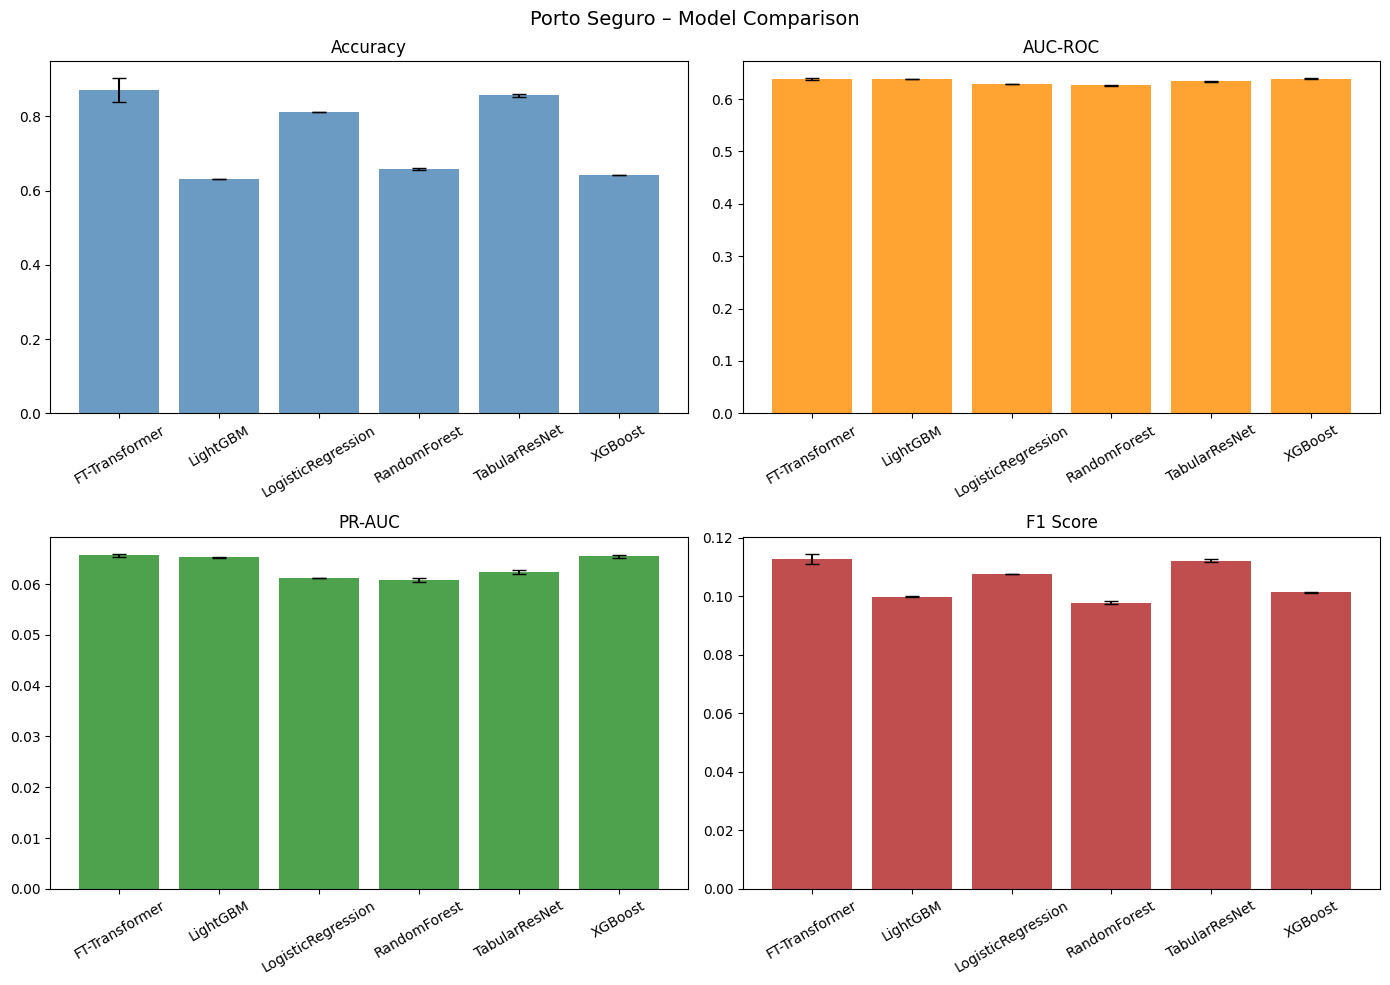

In [63]:
methods = summary.index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(methods, summary['acc_mean'].values, yerr=summary['acc_std'].values,
               capsize=5, color='steelblue', alpha=0.8)
axes[0, 0].set_title('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=30)

axes[0, 1].bar(methods, summary['auc_mean'].values, yerr=summary['auc_std'].values,
               capsize=5, color='darkorange', alpha=0.8)
axes[0, 1].set_title('AUC-ROC')
axes[0, 1].tick_params(axis='x', rotation=30)

axes[1, 0].bar(methods, summary['pr_auc_mean'].values, yerr=summary['pr_auc_std'].values,
               capsize=5, color='forestgreen', alpha=0.8)
axes[1, 0].set_title('PR-AUC')
axes[1, 0].tick_params(axis='x', rotation=30)

axes[1, 1].bar(methods, summary['f1_mean'].values, yerr=summary['f1_std'].values,
               capsize=5, color='firebrick', alpha=0.8)
axes[1, 1].set_title('F1 Score')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.suptitle('Porto Seguro – Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Training Curves: ResNet vs FT-Transformer

n_seeds = len(SEEDS)

color_train = "#4C72B0"   # blue
color_val   = "#DD8452"   # orange

plt.style.use("ggplot")

fig, axes = plt.subplots(2, n_seeds, figsize=(5 * n_seeds, 8), sharex=True)

# Ensure axes shape is consistent
if n_seeds == 1:
    axes = axes.reshape(2, 1)

# ResNet (top row)
for i, seed in enumerate(SEEDS):
    ax = axes[0, i]

    if seed in resnet_train_curves:
        tr_l, va_l = resnet_train_curves[seed]

        ax.plot(tr_l, label="Train", color=color_train, linewidth=1.5)
        ax.plot(va_l, label="Validation", color=color_val, linestyle="--", linewidth=1.5)

    ax.set_title(f"ResNet (Seed {seed})")
    ax.set_ylabel("BCE Loss")

# FT-Transformer (bottom row)
for i, seed in enumerate(SEEDS):
    ax = axes[1, i]

    if seed in ft_train_curves:
        tr_l, va_l = ft_train_curves[seed]

        ax.plot(tr_l, label="Train", color=color_train, linewidth=1.5)
        ax.plot(va_l, label="Validation", color=color_val, linestyle="--", linewidth=1.5)

    ax.set_title(f"FT-Transformer (Seed {seed})")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE Loss")

# Single legend (top-left plot)
axes[0, 0].legend(loc="upper right")

# Final layout
fig.suptitle("Training Curves: ResNet vs FT-Transformer", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

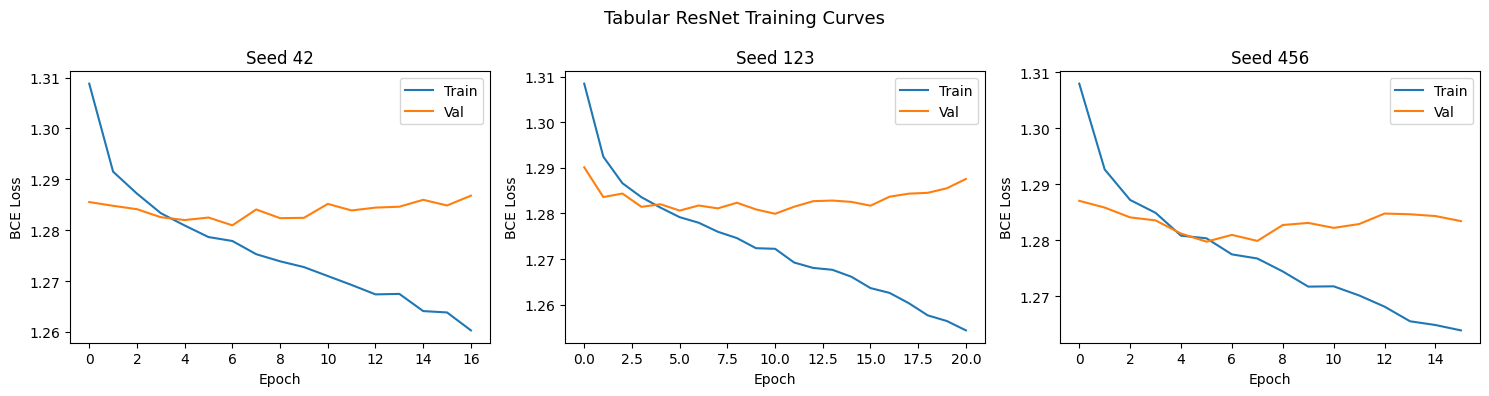

In [64]:
# Tabular ResNet training curves
fig, axes = plt.subplots(1, len(SEEDS), figsize=(15, 4))
for ax, seed in zip(axes, SEEDS):
    tr_l, va_l = rn_train_curves[seed]
    ax.plot(tr_l, label='Train')
    ax.plot(va_l, label='Val')
    ax.set_title(f'Seed {seed}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.legend()
plt.suptitle('Tabular ResNet Training Curves', fontsize=13)
plt.tight_layout()
plt.show()

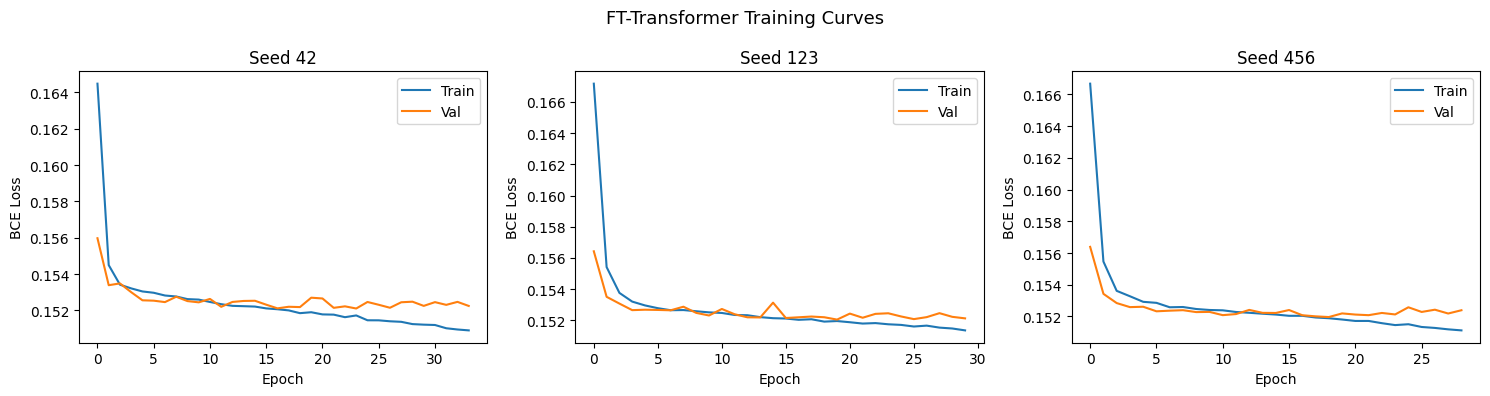

In [65]:
# FT-Transformer training curves
fig, axes = plt.subplots(1, len(SEEDS), figsize=(15, 4))
for ax, seed in zip(axes, SEEDS):
    tr_l, va_l = ft_train_curves[seed]
    ax.plot(tr_l, label='Train')
    ax.plot(va_l, label='Val')
    ax.set_title(f'Seed {seed}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.legend()
plt.suptitle('FT-Transformer Training Curves', fontsize=13)
plt.tight_layout()
plt.show()


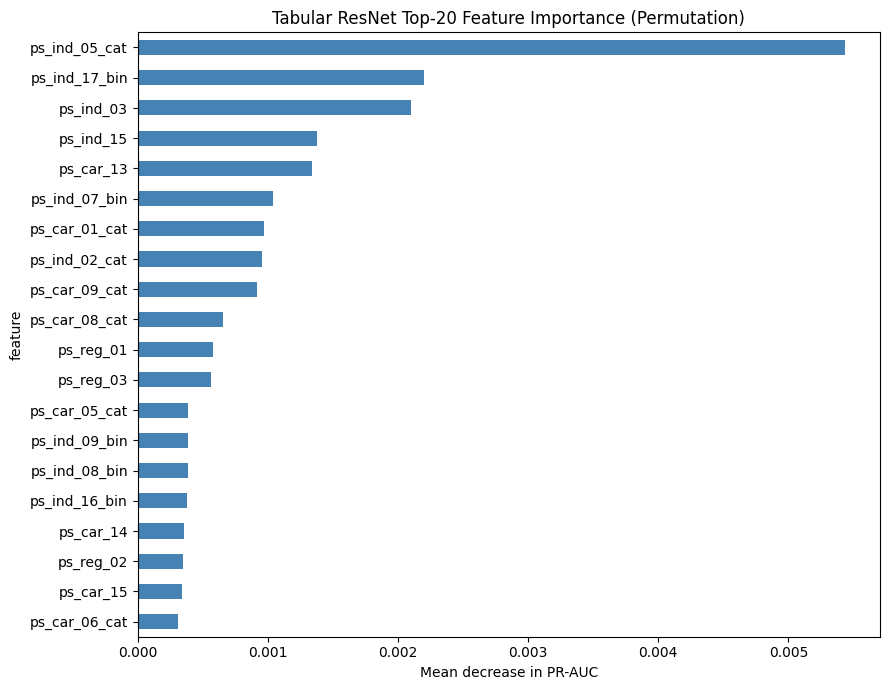

In [ ]:
# Tabular Resnet feature importance (top 15)
# Permutation importance: for each feature, shuffle it and measure
# the drop in PR-AUC on the test set. Average over 5 repetitions.

feat_names_dl = list(num_cols_ps) + list(cat_cols_filtered)
n_num_fi = len(num_cols_ps)

def rn_predict_prob(X_num_arr, X_cat_arr):
    """Return predicted probabilities for TabularResNet (last trained model)."""
    raw = predict_dl_models(rn_model_last, X_num_arr.astype(np.float32),
                                 X_cat_arr.astype(np.int64), str(device))
    return torch.sigmoid(torch.tensor(raw)).numpy()

# Baseline score on test set
base_prob_rn = rn_predict_prob(X_te_num, X_te_cat)
base_score_rn = average_precision_score(y_test_ps, base_prob_rn)

rng_fi = np.random.default_rng(42)
importances_rn = []
for fi_idx, feat in enumerate(feat_names_dl):
    rep_scores = []
    for _ in range(5):
        if fi_idx < n_num_fi:
            X_num_p = X_te_num.copy()
            X_num_p[:, fi_idx] = rng_fi.permutation(X_num_p[:, fi_idx])
            prob_p = rn_predict_prob(X_num_p, X_te_cat)
        else:
            X_cat_p = X_te_cat.copy()
            X_cat_p[:, fi_idx - n_num_fi] = rng_fi.permutation(X_cat_p[:, fi_idx - n_num_fi])
            prob_p = rn_predict_prob(X_te_num, X_cat_p)
        rep_scores.append(base_score_rn - average_precision_score(y_test_ps, prob_p))
    importances_rn.append(np.mean(rep_scores))

fi_df_rn = pd.DataFrame({'feature': feat_names_dl, 'importance': importances_rn})
fi_df_rn = fi_df_rn.sort_values('importance', ascending=True).tail(15)
fi_df_rn.plot.barh(x='feature', y='importance', figsize=(9, 7),
                   legend=False, color='steelblue')
plt.title('Tabular ResNet Top-15 Feature Importance (Permutation)')
plt.xlabel('Mean decrease in PR-AUC')
plt.tight_layout()
plt.show()


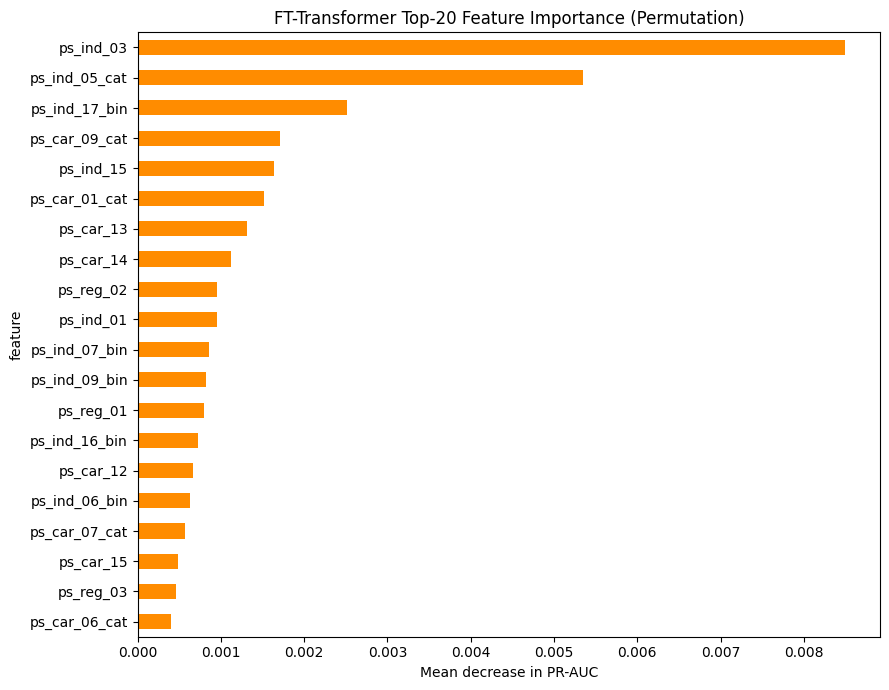

In [ ]:
# FT-Transformer feature importance (top 15)
# Permutation importance: reuse feat_names_dl and n_num_fi from the ResNet cell above.

def ft_predict_prob(X_num_arr, X_cat_arr):
    """Return predicted probabilities for FT-Transformer (last trained model)."""
    raw = predict_dl_models(ft_model_last, X_num_arr.astype(np.float32),
                                 X_cat_arr.astype(np.int64), str(device), batch_size=N_BATCH_SIZE)
    return torch.sigmoid(torch.tensor(raw)).numpy()

# Baseline score on test set
base_prob_ft_fi = ft_predict_prob(X_te_num, X_te_cat)
base_score_ft_fi = average_precision_score(y_test_ps, base_prob_ft_fi)

rng_fi_ft = np.random.default_rng(42)
importances_ft_fi = []
for fi_idx, feat in enumerate(feat_names_dl):
    rep_scores = []
    for _ in range(5):
        if fi_idx < n_num_fi:
            X_num_p = X_te_num.copy()
            X_num_p[:, fi_idx] = rng_fi_ft.permutation(X_num_p[:, fi_idx])
            prob_p = ft_predict_prob(X_num_p, X_te_cat)
        else:
            X_cat_p = X_te_cat.copy()
            X_cat_p[:, fi_idx - n_num_fi] = rng_fi_ft.permutation(X_cat_p[:, fi_idx - n_num_fi])
            prob_p = ft_predict_prob(X_te_num, X_cat_p)
        rep_scores.append(base_score_ft_fi - average_precision_score(y_test_ps, prob_p))
    importances_ft_fi.append(np.mean(rep_scores))

fi_df_ft = pd.DataFrame({'feature': feat_names_dl, 'importance': importances_ft_fi})
fi_df_ft = fi_df_ft.sort_values('importance', ascending=True).tail(15)
fi_df_ft.plot.barh(x='feature', y='importance', figsize=(9, 7),
                   legend=False, color='darkorange')
plt.title('FT-Transformer Top-15 Feature Importance (Permutation)')
plt.xlabel('Mean decrease in PR-AUC')
plt.tight_layout()
plt.show()


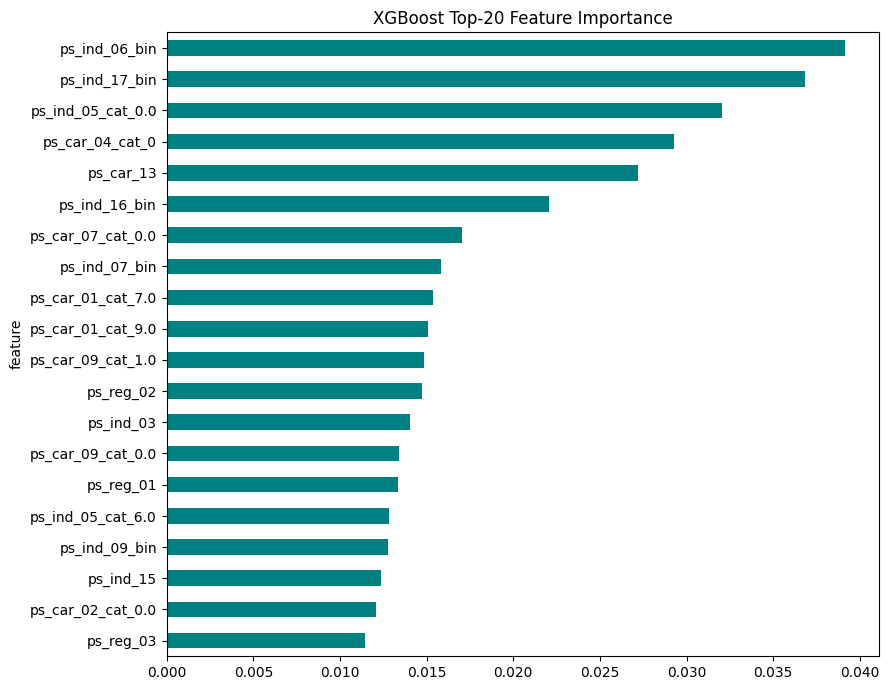

In [ ]:
# XGBoost feature importance (top 15)
if xgb_model_last is not None:
    fi = xgb_model_last.feature_importances_
    feat_names = num_cols_ps + onehot_enc_ps.get_feature_names_out(cat_cols_filtered).tolist()
    fi_df = pd.DataFrame({'feature': feat_names, 'importance': fi})
    fi_df = fi_df.sort_values('importance', ascending=True).tail(15)
    fi_df.plot.barh(x='feature', y='importance', figsize=(9, 7),
                    legend=False, color='teal')
    plt.title('XGBoost Top-15 Feature Importance')
    plt.tight_layout()
    plt.show()


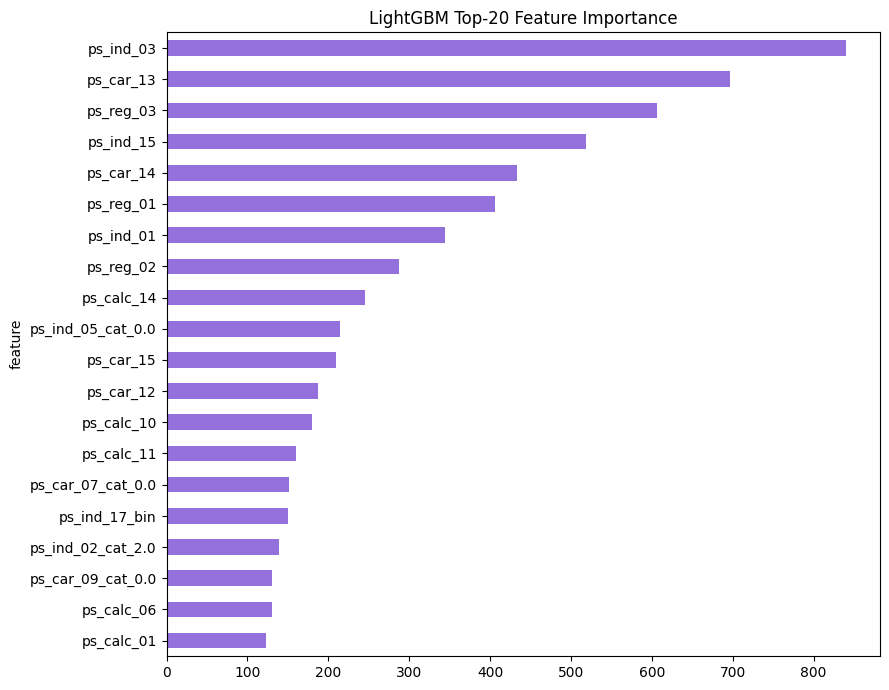

In [ ]:
# LightGBM feature importance (top 15)
if lgb_model_last is not None:
    fi = lgb_model_last.feature_importances_
    feat_names = num_cols_ps + onehot_enc_ps.get_feature_names_out(cat_cols_filtered).tolist()
    fi_df = pd.DataFrame({'feature': feat_names, 'importance': fi})
    fi_df = fi_df.sort_values('importance', ascending=True).tail(15)
    fi_df.plot.barh(x='feature', y='importance', figsize=(9, 7),
                    legend=False, color='mediumpurple')
    plt.title('LightGBM Top-15 Feature Importance')
    plt.tight_layout()
    plt.show()


## Analysis & Conclusions

### Summary
We benchmarked six models on the Porto Seguro safe-driver prediction task.

- The dataset is **severely imbalanced** (~3.6 % positive), so **PR-AUC** is the best metric.
- **LightGBM** with `is_unbalance=True` and **XGBoost** with `scale_pos_weight`
  are well-suited for this imbalanced setting.
- **FT-Transformer** uses learned categorical embeddings, which can capture
  non-linear interactions between the many categorical features.
- **Tabular ResNet** uses skip connections to learn deep tabular representations.
- **Random Forest** with `class_weight='balanced'` offers a strong tree baseline.

### Observations
- Gini scores on **synthetic** data are near 0 because the synthetic labels are
  random (independent of features). Real data results will differ substantially.
- The preprocessing pipeline — replacing -1 sentinels, mode/median imputation,
  OrdinalEncoding — mirrors common Kaggle solutions for this competition.
- 3-seed evaluation reduces variance in reported Gini.

### Next Steps
- Feature engineering: polynomial interactions among `ps_reg` features.
- Calibrated probability outputs for better threshold tuning.
- Stacking / blending of LightGBM + XGBoost predictions.
- SHAP analysis to understand which feature groups drive predictions.
